/tmp/ipykernel_7035/3512628038.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("GOOG", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker           GOOG
Date                 
2015-01-02  25.955561
2015-01-05  25.414499
2015-01-06  24.825466
2015-01-07  24.782934
2015-01-08  24.861078
Data preprocessing done



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 0.0131 - val_loss: 0.0025
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 4.4310e-04 - val_loss: 0.0025
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 4.2003e-04 - val_loss: 0.0018
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 4.1076e-04 - val_loss: 0.0030
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 4.8327e-04 - val_loss: 0.0017
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Train RMSE: 2.8159880931988286
Test RMSE : 5.228180399737761


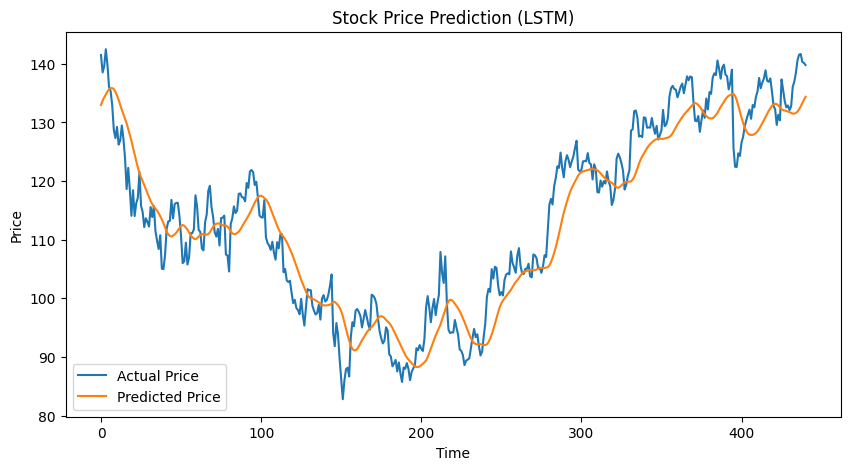

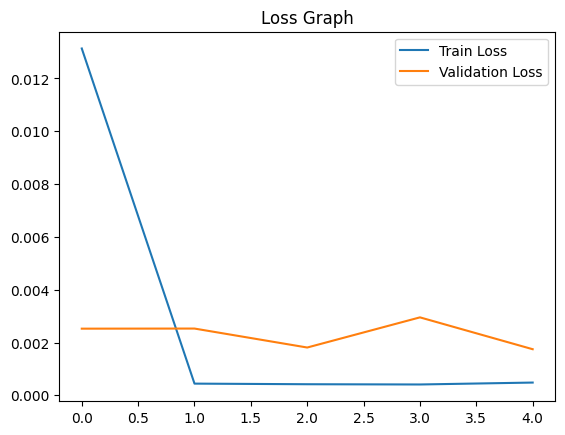

In [ ]:
# ==========================================
# Assignment 9: RNN (LSTM) for Stock Prediction
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# ------------------------------------------
# 1. Load Dataset (AUTO from Yahoo Finance)
# ------------------------------------------
import yfinance as yf

# Download stock data (Google)
data = yf.download("GOOG", start="2015-01-01", end="2024-01-01")

# Use closing price
df = data[['Close']]

print(df.head())




scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)


def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# Reshape for RNN [samples, time_steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Data preprocessing done")

# ------------------------------------------
# 3. Build RNN (LSTM Model)
# ------------------------------------------

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step,1)),
    LSTM(50),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

# ------------------------------------------
# 4. Train Model
# ------------------------------------------

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# ------------------------------------------
# 5. Predictions
# ------------------------------------------

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Inverse transform
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))



from sklearn.metrics import mean_squared_error

train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))

print("\nTrain RMSE:", train_rmse)
print("Test RMSE :", test_rmse)

# ------------------------------------------
# 7. Visualization: Predictions vs Actual
# ------------------------------------------

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(test_pred, label="Predicted Price")
plt.title("Stock Price Prediction (LSTM)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

# ------------------------------------------
# 8. Loss Graph
# ------------------------------------------

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Graph")
plt.legend()
plt.show()